<a href="https://colab.research.google.com/github/nmatsumoto-lgtm/study-KIKAGAKU/blob/main/%E5%BF%83%E8%87%93%E7%97%85%E3%81%AE%E4%BA%88%E6%B8%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_train = pd.read_csv('/content/drive/MyDrive/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/test.csv')

* id: ID
* Age: 年齢
* Sex: 性別
* Chest pain type: 胸痛の種類
* BP: 血圧
* Cholesterol: コレステロール
* FBS over 120: 空腹時血糖値120超
* EKG results: 心電図結果
* Max HR: 最大心拍数
* Exercise angina: 運動誘発性狭心症
* ST depression: ST低下
* Slope of ST: STセグメントの傾き
* Number of vessels fluro: 蛍光透視下の血管数
* Thallium: タリウム
* Heart Disease: 心臓病
* Presence: 存在 / あり
* Absence: 不在 / なし

In [3]:
df_train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
df_train.shape, df_test.shape

((630000, 15), (270000, 14))

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: f

In [7]:
df_train['Heart Disease'].value_counts()

,count
Heart Disease,
Absence,347546
Presence,282454


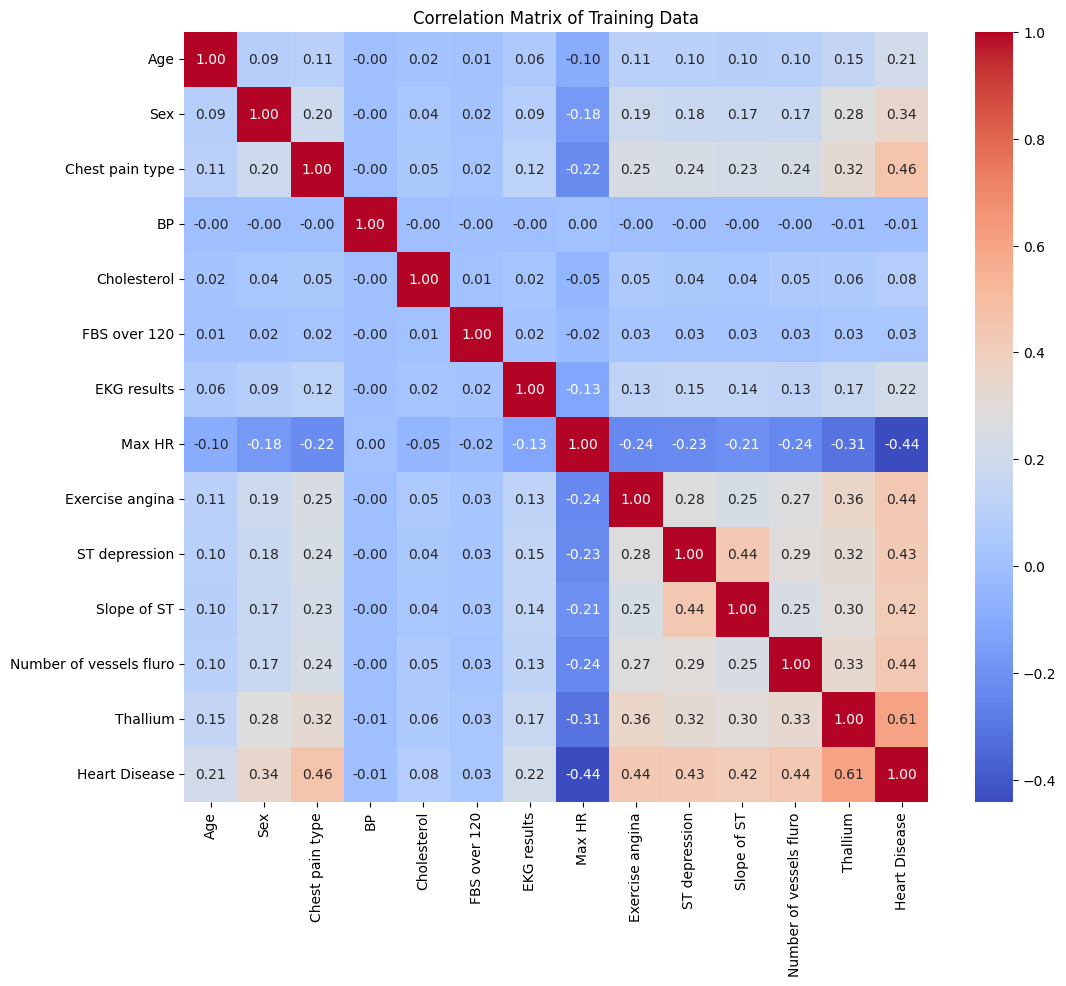

In [8]:
df_train_heatmap = df_train.copy()
# 'Heart Disease'列を数値に変換: 'Presence'を1、'Absence'を0とする
df_train_heatmap['Heart Disease'] = df_train_heatmap['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# 'id'列は相関分析には不要なので除外
df_train_heatmap = df_train_heatmap.drop('id', axis=1)

# 相関行列を計算
correlation_matrix = df_train_heatmap.corr()

# ヒートマップを作成
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Training Data')
plt.show()

### 各特徴量の分布を可視化し、`Heart Disease`との関係を見る

### 特徴量エンジニアリング

XGBoostモデルの性能を向上させるため、カテゴリカル特徴量のエンコーディングを行います。

*   `Heart Disease` は目的変数として数値（`Presence`: 1, `Absence`: 0）に変換します。
*   `id` はモデル学習には不要なため削除します。
*   `Sex`, `FBS over 120` は既にバイナリ値なので、そのまま使用します。
*   `Chest pain type`, `EKG results`, `Slope of ST`, `Thallium` はカテゴリカル特徴量としてワンホットエンコーディングを適用します。

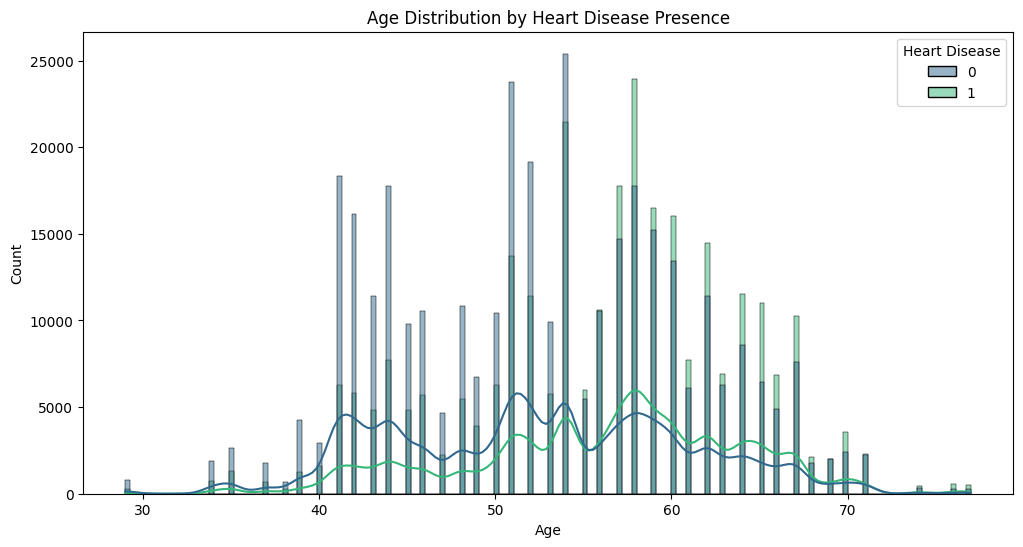

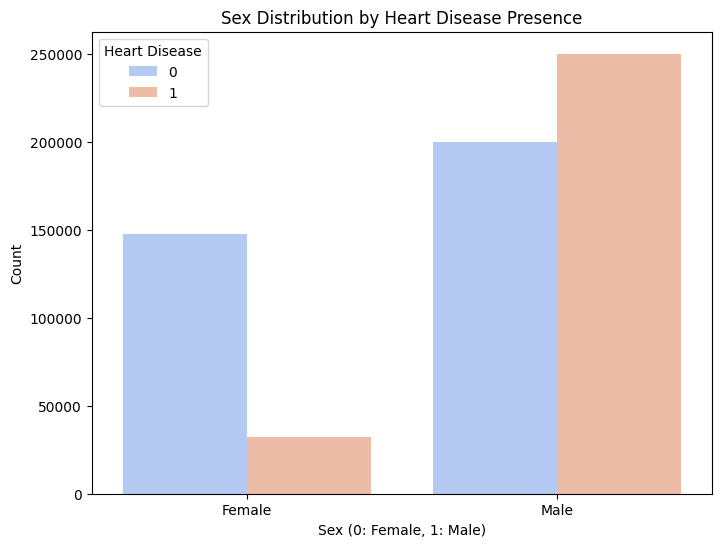

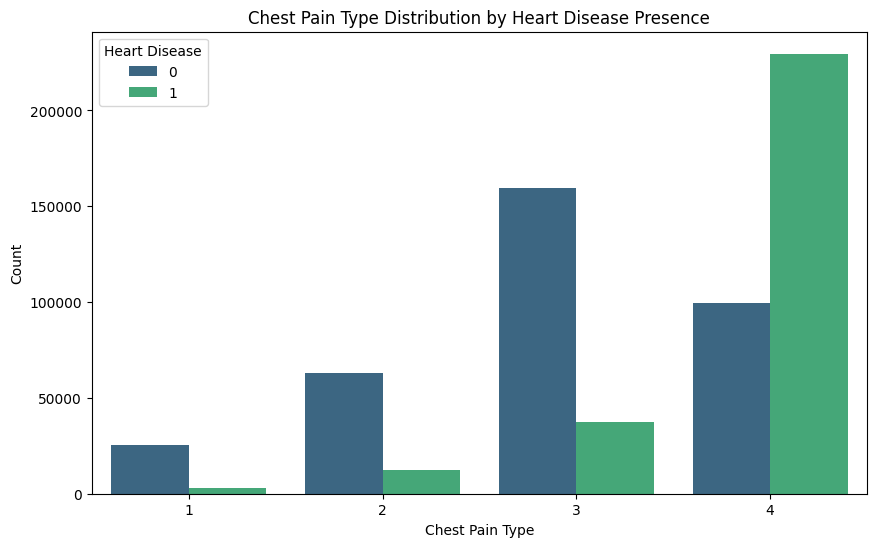

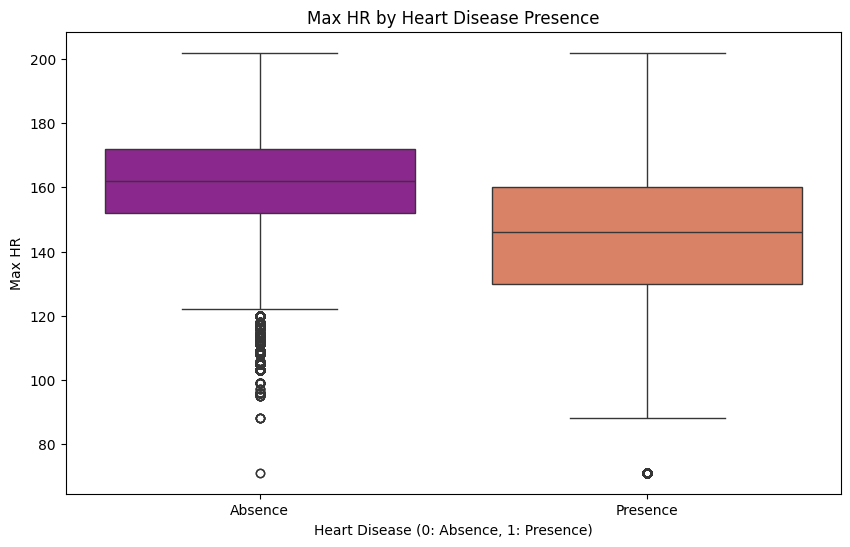

In [9]:
# 'Heart Disease'列を数値に変換（既に前のセルで実施済みですが、再度確認のため）
df_train_plot = df_train.copy()
df_train_plot['Heart Disease'] = df_train_plot['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# 年齢の分布をヒストグラムとKDEで表示し、Heart Diseaseの有無で色分け
plt.figure(figsize=(12, 6))
sns.histplot(data=df_train_plot, x='Age', hue='Heart Disease', kde=True, palette='viridis')
plt.title('Age Distribution by Heart Disease Presence')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# 性別のカウントをHeart Diseaseの有無で比較
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train_plot, x='Sex', hue='Heart Disease', palette='coolwarm')
plt.title('Sex Distribution by Heart Disease Presence')
plt.xlabel('Sex (0: Female, 1: Male)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.show()

# Chest pain typeのカウントをHeart Diseaseの有無で比較
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train_plot, x='Chest pain type', hue='Heart Disease', palette='viridis')
plt.title('Chest Pain Type Distribution by Heart Disease Presence')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()

# Max HR (最大心拍数) と Heart Disease の関係を箱ひげ図で比較
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_train_plot, x='Heart Disease', y='Max HR', palette='plasma')
plt.title('Max HR by Heart Disease Presence')
plt.xlabel('Heart Disease (0: Absence, 1: Presence)')
plt.ylabel('Max HR')
plt.xticks(ticks=[0, 1], labels=['Absence', 'Presence'])
plt.show()

In [10]:
# データセットのコピーを作成
df_train_fe = df_train.copy()
df_test_fe = df_test.copy()

# 'Heart Disease'を数値に変換 (トレーニングデータのみ)
df_train_fe['Heart Disease'] = df_train_fe['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# id列を削除
df_train_fe = df_train_fe.drop('id', axis=1)
df_test_fe = df_test_fe.drop('id', axis=1)

# カテゴリカル特徴量のリスト
categorical_features = [
    'Chest pain type',
    'EKG results',
    'Slope of ST',
    'Thallium'
]

# ワンホットエンコーディングの適用
df_train_fe = pd.get_dummies(df_train_fe, columns=categorical_features, drop_first=True, dtype=int)
df_test_fe = pd.get_dummies(df_test_fe, columns=categorical_features, drop_first=True, dtype=int)

# 特徴量エンジニアリング後のデータフレームの最初の5行を表示
print("df_train_fe head:")
display(df_train_fe.head())
print("\ndf_test_fe head:")
display(df_test_fe.head())

# 変換後のデータフレームの形状を確認
print(f"\nShape of df_train_fe after feature engineering: {df_train_fe.shape}")
print(f"Shape of df_test_fe after feature engineering: {df_test_fe.shape}")

df_train_fe head:


,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,Heart Disease,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
0,58,1,152,239,0,158,1,3.6,2,1,0,0,1,0,0,1,0,0,1
1,52,1,125,325,0,171,0,0.0,0,0,0,0,0,0,1,0,0,0,0
2,56,0,160,188,0,151,0,0.0,0,0,1,0,0,0,1,0,0,0,0
3,44,0,134,229,0,150,0,1.0,0,0,0,1,0,0,1,1,0,0,0
4,58,1,140,234,0,125,1,3.8,3,1,0,0,1,0,1,1,0,0,0



df_test_fe head:


,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
0,58,1,120,288,0,145,1,0.8,3,0,1,0,0,1,1,0,0,0
1,55,0,120,209,0,172,0,0.0,0,1,0,0,0,0,0,0,0,0
2,54,1,120,268,0,150,1,0.0,3,0,0,1,0,0,1,0,0,1
3,44,0,112,177,0,168,0,0.9,0,0,1,0,0,0,0,0,0,0
4,43,1,138,267,0,163,0,1.8,0,0,0,0,0,0,1,0,0,1



Shape of df_train_fe after feature engineering: (630000, 19)
Shape of df_test_fe after feature engineering: (270000, 18)


### XGBoostモデルの学習と評価

特徴量エンジニアリングが完了したデータセットを使用して、XGBoost分類モデルを学習し、交差検証（cross-validation）でその性能を評価します。これにより、モデルが未知のデータに対してどの程度の精度を発揮するかを推定できます。

In [11]:
# 特徴量 (X) と目的変数 (y) の分離
X = df_train_fe.drop('Heart Disease', axis=1)
y = df_train_fe['Heart Disease']

# XGBoostClassifierのインスタンス化
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# 層化K分割交差検証の設定
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 交差検証の実行
# accuracy_scoreではなく、cross_val_scoreで'accuracy'を指定することで、交差検証による精度を計算
scores = cross_val_score(xgb_model, X, y, cv=skf, scoring='accuracy')

print(f"各分割での精度: {scores}")
print(f"平均精度: {scores.mean():.4f}")
print(f"精度標準偏差: {scores.std():.4f}")

各分割での精度: [0.88910317 0.88620635 0.88853968 0.88733333 0.88804762]
平均精度: 0.8878
精度標準偏差: 0.0010


In [17]:
# 全学習データでモデルを再学習
xgb_model.fit(X, y)

# テストデータで予測確率を取得
# predict_probaは[確率0, 確率1]の形式で返すため、クラス1の確率（Heart Disease='Presence'の確率）を取得します。
test_probabilities = xgb_model.predict_proba(df_test_fe)[:, 1]

# 提出用ファイルの作成
# df_test に含まれるオリジナルの 'id' を使用し、'Heart Disease'列に予測確率を格納
submission_df = pd.DataFrame({'id': df_test['id'], 'Heart Disease': test_probabilities})

print("予測結果（最初の5行）:")
display(submission_df.head())

# Google DriveのマイドライブにCSVとして保存
submission_df.to_csv('/content/drive/MyDrive/submission.csv', index=False)
print("予測結果を 'Google Drive/MyDrive/submission.csv' として保存しました。")

予測結果（最初の5行）:


,id,Heart Disease
0,630000,0.975096
1,630001,0.011763
2,630002,0.985957
3,630003,0.007152
4,630004,0.199670


予測結果を 'Google Drive/MyDrive/submission.csv' として保存しました。
